Next, using your cleaned-up dataset, have your code come up with an estimate 
for both the depth of the transit in units of relative flux and for its length in 
days. Using the transit depth D, you can estimate the radius of the exoplanet using 
the following equation (assume the radius of the star is one solar radii): 

notes: 

In [19]:
#general set up
from astropy.table import QTable
import numpy as np

['time [days]', 'flux']


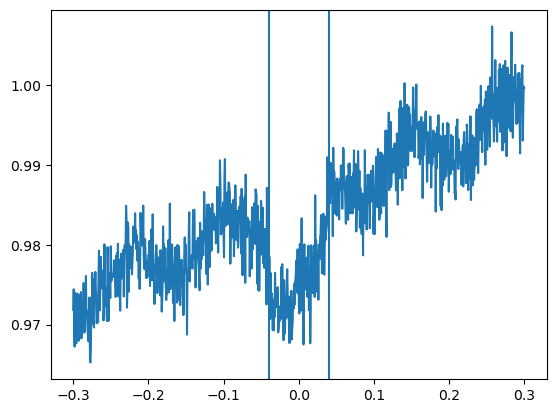

In [21]:
#assume that youve been given two arrays
# x_values: array
# y_values : array

#getting data

Data = QTable.read("Planet_Lightcurve.fits", format='fits')
print(Data.colnames)
import matplotlib.pyplot as plt
plt.plot(Data['time [days]'], Data['flux'])
plt.axvline(0.04)
plt.axvline(-0.04)

In [23]:
#assuming I have two arrays 
# time_clean : x-axis
# flux_clean: y-axis

#dummy values for testing

time_clean = Data['time [days]']
flux_clean = Data['flux']

#set up

from astropy import constants as const
solar_radii = const.R_sun

#bounds

transit_mask = (time_clean >= -0.04) & (time_clean <= 0.04)

#duration

time_intransit = time_clean[transit_mask]
trans_start, trans_end = [time_intransit][0], [time_intransit][-1]
transit_length = trans_end - trans_start

#caluculate depth

out_of_transit = np.mean(flux_clean[~transit_mask])
in_transit = np.mean(flux_clean[transit_mask])
depth = out_of_transit - in_transit

#exoplanet radius

Rstar = solar_radii
Rplanet = Rstar * np.sqrt(depth)